In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sp

In [3]:
df=pd.read_csv("titanic.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


MEAN

In [4]:
mn=np.mean(df["Age"])
print(mn)

29.69911764705882


MEDIAN

In [5]:
a=df["Age"].fillna(method="bfill")
me=np.median(a)
print(me)

29.0


C:\Users\mitad\AppData\Local\Temp\ipykernel_16308\27625113.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  a=df["Age"].fillna(method="bfill")


MODE

In [6]:
md=df["Age"].mode()
g=df["Age"].value_counts()
print(md,g.head(10))

0    24.0
Name: Age, dtype: float64 Age
24.0    30
22.0    27
18.0    26
28.0    25
30.0    25
19.0    25
21.0    24
25.0    23
36.0    22
29.0    20
Name: count, dtype: int64


SKEWNESS

In [7]:
print(df["Age"].skew())

0.38910778230082704


STANDARD DEVIATION AND VARIENCE

In [8]:
v=np.var(df['Age'])
st=np.std(df["Age"])
mdv=np.mean(df["Age"]-mn)
print(v)
print(st)
print(mdv)

210.72357975366614
14.516321150817316
3.8214063099702865e-15


GRAPH PLOT

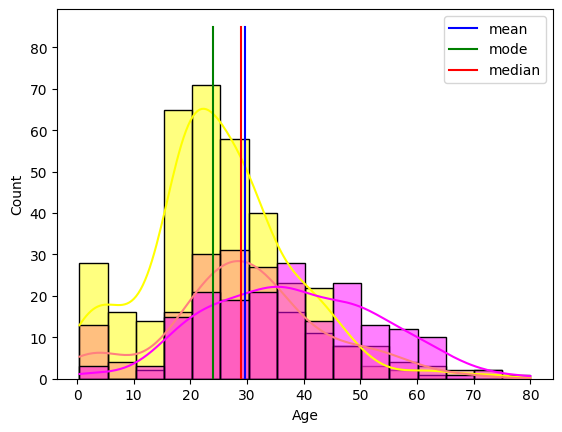

In [9]:
sns.histplot(data=df, x="Age",kde=True,hue="Pclass", palette="spring",bins=16)
plt.plot([mn for i in range(86)],[i for i in range(86)], color="blue", label="mean")
plt.plot([md for i in range(86)],[i for i in range(86)], color="green",label="mode")
plt.plot([me for i in range(86)],[i for i in range(86)], color="red",label="median")
plt.legend()
plt.show()

OUTLIARS

       PassengerId    Survived      Pclass         Age       SibSp  \
count   825.000000  825.000000  825.000000  825.000000  825.000000   
mean    447.369697    0.380606    2.341818   28.879689    0.507879   
std     257.088865    0.485830    0.824096   10.182710    1.090670   
min       1.000000    0.000000    1.000000    3.000000    0.000000   
25%     226.000000    0.000000    2.000000   22.000000    0.000000   
50%     445.000000    0.000000    3.000000   29.699118    0.000000   
75%     671.000000    1.000000    3.000000   34.000000    1.000000   
max     891.000000    1.000000    3.000000   54.000000    8.000000   

            Parch        Fare  
count  825.000000  825.000000  
mean     0.357576   31.483615  
std      0.798599   49.956429  
min      0.000000    0.000000  
25%      0.000000    7.895800  
50%      0.000000   13.416700  
75%      0.000000   30.070800  
max      6.000000  512.329200  


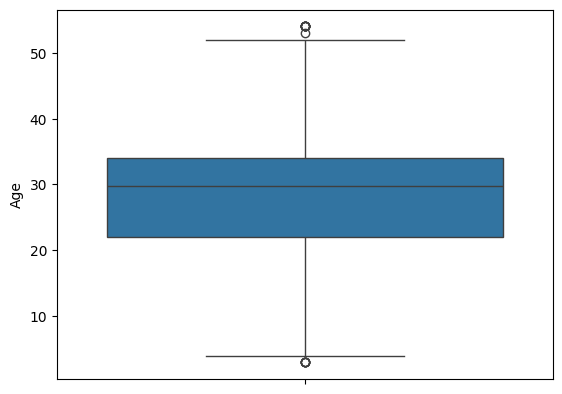

In [10]:
df["Age"]=df["Age"].replace(np.nan,mn)
Q1=np.percentile(df["Age"],25)
Q3=np.percentile(df["Age"],75)
IQR= Q3-Q1
LF=Q1-1.5*IQR
UF=Q3+1.5*IQR
dfc=df[(df["Age"]>LF) & (df["Age"]<UF)]
print(dfc.describe())
sns.boxplot(data=dfc, y="Age")
plt.show()

COVARIENCE AND CORRELATION

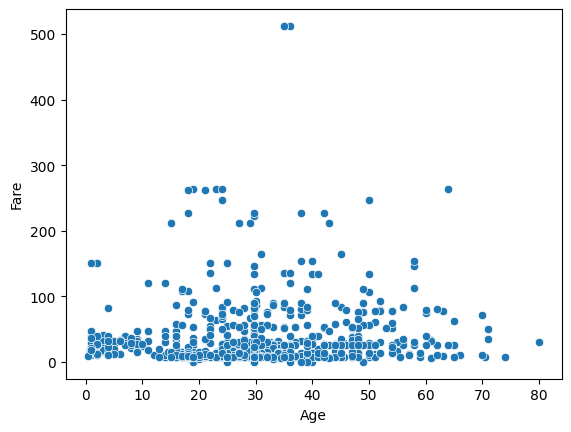

In [11]:
sns.scatterplot(data=df,x="Age",y="Fare")
plt.show()
o=df[["Age","Fare"]].corr()

In [12]:
df.select_dtypes("float64","int64").corr()
#gives all the data of the given type parameter

,Age,Fare
Age,1.000000,0.091566
Fare,0.091566,1.000000


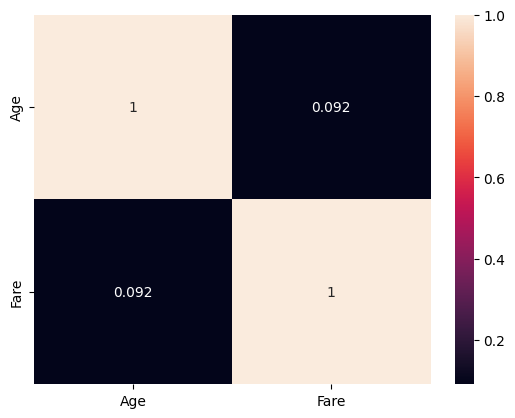

<Figure size 100x100 with 0 Axes>

In [13]:
sns.heatmap(data=o, annot=True)
plt.figure(figsize=[1,1])
plt.show()

CENTRAL LIMIT THEOREM

np.float64(0.4344880940129925)

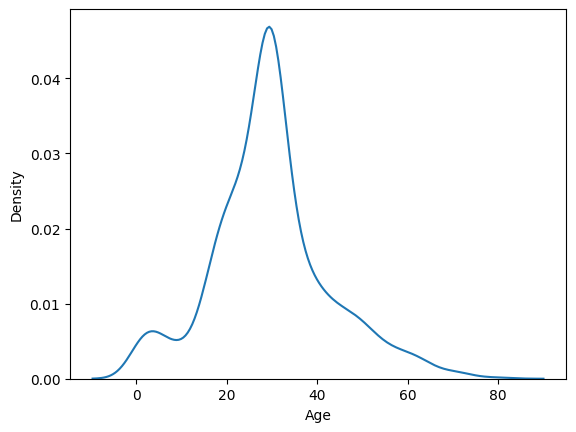

In [14]:
sns.kdeplot(data=df, x="Age")
df["Age"].skew()

In [15]:
r=[]
for j in range(60):
    q=[]
    for i in range(30):
        q.append(int(np.random.choice(df["Age"])))
    r.append(q)
data=pd.DataFrame(r)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       60 non-null     int64
 1   1       60 non-null     int64
 2   2       60 non-null     int64
 3   3       60 non-null     int64
 4   4       60 non-null     int64
 5   5       60 non-null     int64
 6   6       60 non-null     int64
 7   7       60 non-null     int64
 8   8       60 non-null     int64
 9   9       60 non-null     int64
 10  10      60 non-null     int64
 11  11      60 non-null     int64
 12  12      60 non-null     int64
 13  13      60 non-null     int64
 14  14      60 non-null     int64
 15  15      60 non-null     int64
 16  16      60 non-null     int64
 17  17      60 non-null     int64
 18  18      60 non-null     int64
 19  19      60 non-null     int64
 20  20      60 non-null     int64
 21  21      60 non-null     int64
 22  22      60 non-null     int64
 23  23      60 non-nu

In [16]:
mean=[]
for i in data:
    mean.append(np.mean(data[i]))
dt=pd.DataFrame(mean)

-1.3457409993254732 29.69911764705882 29.299444444444443


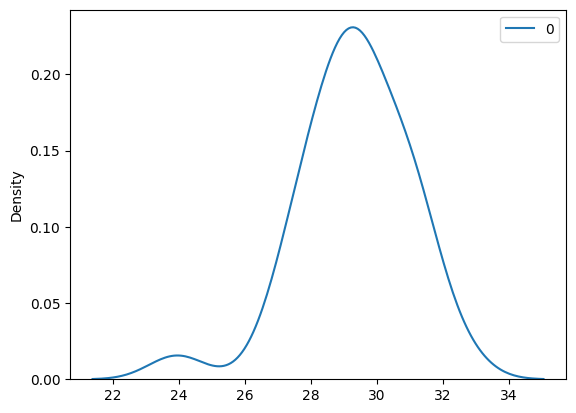

In [17]:
sns.kdeplot(data=dt)
m=np.mean(mean)
error=(m/mn-1)*100
print(error,mn,m)

HYPOTHESIS TESTING

Z-TESTING

In [18]:
l=[]
for i in range(60):
    l.append(np.random.choice(df["Age"]))
n=len(l)
x=mn
u=np.mean(l)
o=np.std(df["Age"])
z_test=(x-u)/(o/np.sqrt(n))
z_table=sp.norm.ppf(1-0.025)
if(np.abs(z_test)>=z_table):
    print("ha")
else:
    print("ho")

ho


T-TEST

In [19]:
l1=[]
for i in range(20):
    l1.append(np.random.choice(df["Age"]))
l2=[]
for i in range(20):
    l2.append(np.random.choice(df["Age"]))
n1=len(l1)
n2=len(l2)
x=np.mean(l1)
u=np.mean(l2)
o=np.std(df["Age"])
t_test=(x-u)/(o/np.sqrt((n1**2)+(n2**2)))
t_table=sp.t.ppf(1-0.05,38)
if(np.abs(t_test)>=t_table):
    print("ha")
else:
    print("ho")

ha


CHI SQUARE TEST

In [ ]:
l1=[]
for i in range(36):
    l1.append(np.random.choice(df["Age"]))
l2=[]
for i in range(36):
    l2.append(np.random.choice(df["Age"]))
a1=np.array(l1)
a2=np.array(l2)
del l1, l2
c_sum=a1+a2
r_sum=np.array([np.sum(a1),np.sum(a2)])
t=np.sum(c_sum)
l3=[]
for i in r_sum:
    for j in c_sum:
        l3.append(i*j/t)
ex=np.array([l3])
del l3
gd=np.append(a1,a2)
chi_val=np.sum(np.square(gd-ex)/ex)
if(np.abs(chi_val)>=43.773):
    print("ha")
else:
    print("ho")

ha
